In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

In [2]:
df_index=pd.read_csv("economic_index.csv")

In [3]:
df_index.head()

,Unnamed: 0,year,month,interest_rate,unemployment_rate,index_price
0,0,2017,12,2.75,5.3,1464
1,1,2017,11,2.50,5.3,1394
2,2,2017,10,2.50,5.3,1357
3,3,2017,9,2.50,5.3,1293
4,4,2017,8,2.50,5.4,1256


In [4]:
#drop unneccessary columns
df_index.drop(columns=["Unnamed: 0","year","month"],axis=1,inplace=True)

In [5]:
df_index.head()

,interest_rate,unemployment_rate,index_price
0,2.75,5.3,1464
1,2.50,5.3,1394
2,2.50,5.3,1357
3,2.50,5.3,1293
4,2.50,5.4,1256


In [6]:
##check null values
df_index.isnull().sum()

interest_rate        0
unemployment_rate    0
index_price          0
dtype: int64

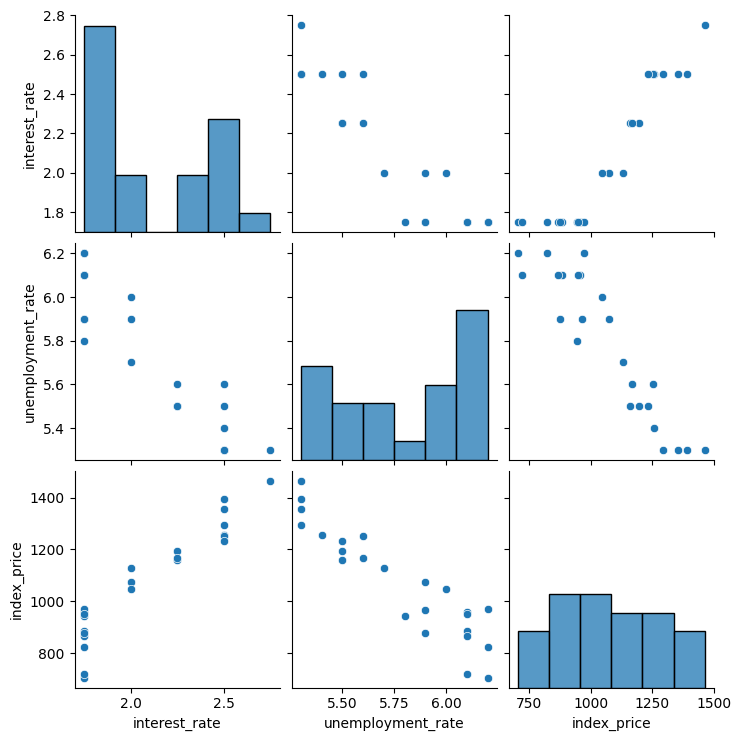

In [7]:
## Lets do some viualization
import seaborn as sns
sns.pairplot(df_index)

In [8]:
df_index.corr()

,interest_rate,unemployment_rate,index_price
interest_rate,1.000000,-0.925814,0.935793
unemployment_rate,-0.925814,1.000000,-0.922338
index_price,0.935793,-0.922338,1.000000


Text(0, 0.5, 'unemployment rate')

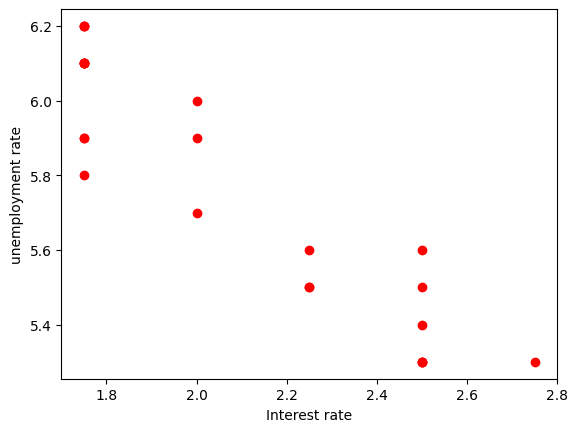

In [9]:
## Visualiza the datapoints more closely
plt.scatter(df_index['interest_rate'],df_index['unemployment_rate'],color='r')
plt.xlabel("Interest rate")
plt.ylabel("unemployment rate")

In [14]:
##independent and dependent features
X=df_index.iloc[:,:-1] ## Select All rows and Select from first column to second last column 
## X = df_index[['interest_rate','unemployement_rate']]
y=df_index.iloc[:,-1] ## Select all rows and select only last column
print(type(y))
## iloc -> It is used to select rows and columns using index positions (numbers).
## df.iloc[row_selection, column_selection]

<class 'pandas.core.series.Series'>


In [11]:
X.head()

,interest_rate,unemployment_rate
0,2.75,5.3
1,2.50,5.3
2,2.50,5.3
3,2.50,5.3
4,2.50,5.4


In [ ]:
y 

0     1464
1     1394
2     1357
3     1293
4     1256
5     1254
6     1234
7     1195
8     1159
9     1167
10    1130
11    1075
12    1047
13     965
14     943
15     958
16     971
17     949
18     884
19     866
20     876
21     822
22     704
23     719
Name: index_price, dtype: int64

In [15]:
# train test split
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=42)

In [19]:
import seaborn as sns

<Axes: xlabel='interest_rate', ylabel='index_price'>

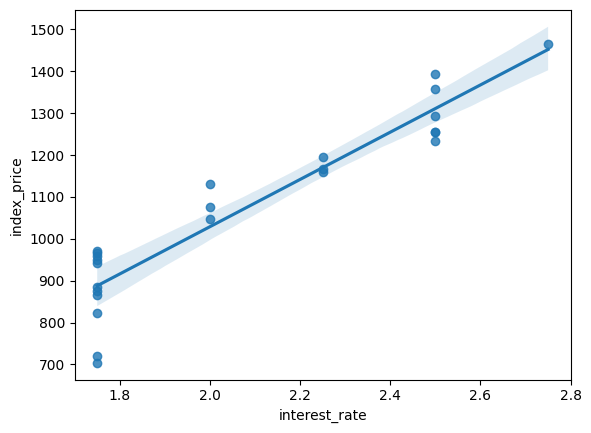

In [ ]:
sns.regplot(x=df_index['interest_rate'],y=df_index['index_price'])
## sns.regplot() -> It combines : Scatter plots, Linear regression fitting with confidence interval visualization
## Blue line shows: Best fit line that predicts index price based on interest rate.(This line is created using linear regression)
## Shaded Region : This is CI(Confidence Interval). It shows: Range where actual regression line likely lies

<Axes: xlabel='interest_rate', ylabel='unemployment_rate'>

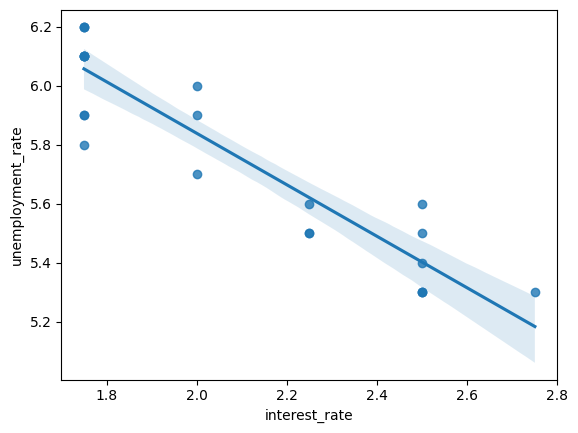

In [23]:
sns.regplot(x=df_index['interest_rate'],y=df_index['unemployment_rate'])

<Axes: xlabel='index_price', ylabel='unemployment_rate'>

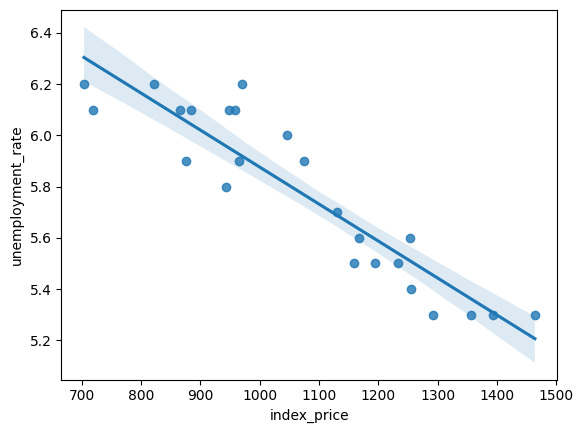

In [24]:
sns.regplot(x=df_index['index_price'],y=df_index['unemployment_rate'])

In [25]:
## Standardization
from sklearn.preprocessing import StandardScaler

In [26]:
scaler=StandardScaler()
## fit_transform -> fit_transform() learns parameters from data (like mean and standard deviation) and then applies the transformation(z-score)to that same data in one step.
X_train=scaler.fit_transform(X_train) 
X_test=scaler.fit_transform(X_test)

In [27]:
X_train

array([[-0.90115511,  0.37908503],
       [ 1.31077107, -1.48187786],
       [-0.90115511,  1.30956648],
       [ 1.31077107, -0.55139641],
       [ 1.31077107, -1.48187786],
       [-0.16384638,  0.68924552],
       [-0.90115511,  0.999406  ],
       [ 1.31077107, -1.48187786],
       [ 1.31077107, -1.17171738],
       [-0.90115511,  1.30956648],
       [-0.90115511,  0.999406  ],
       [-0.90115511,  0.37908503],
       [-0.90115511,  0.999406  ],
       [ 0.57346234, -0.8615569 ],
       [-0.16384638, -0.24123593],
       [-0.90115511,  0.06892455],
       [-0.90115511,  0.999406  ],
       [ 1.31077107, -0.8615569 ]])

In [28]:
from sklearn.linear_model import LinearRegression
regression=LinearRegression()

In [29]:
regression.fit(X_train,y_train) 
## regression.fit(X_train, y_train) trains the regression model by learning the relationship between input features (X_train) and target values (y_train).

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [32]:
## cross validation -> Cross Validation is a technique used to check how well a model performs on unseen data by testing it multiple times on different splits of the dataset.
## Instead of one split: We split data multiple times, Train & test model multiple times, Take average performance
from sklearn.model_selection import cross_val_score
validation_score=cross_val_score(regression,X_train,y_train,scoring='neg_mean_squared_error',
                                cv=3)
## regression -> Model you want to evaluate. Cross validation will: Train this model multiple times, Evaluate performance each time
## scoring='neg_mean_squared_error' -> Defines performance metric.
## Why MSE -> Sklearn assumes: Higher score = Better model, But MSE: Lower value = Better model. So sklearn converts: MSE → Negative MSE

In [ ]:
## cv = 3  Dataset is divided into 3 equal parts:
## Fold 1 → Train (2nd,3rd part) Test (1st part)
## Fold 2 → Train (1nd,3rd part) Test (2st part)
## Fold 3 → Train (1st,2nd part) Test (3st part)
validation_score ## It returns an array containing MSE for each fold 


array([-4921.61331265, -7686.87497294, -5135.9962549 ])

In [35]:
print(np.mean(validation_score))

-5914.828180162388


In [36]:
## prediction
y_pred=regression.predict(X_test)

In [37]:
y_pred

array([1180.7466813 ,  802.74279699, 1379.83457045,  838.52599602,
        973.85313963, 1144.96348227])

In [38]:
## Performance Metrics
from sklearn.metrics import mean_absolute_error,mean_squared_error
mse=mean_squared_error(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
rmse=np.sqrt(mse)
print(mse)
print(mae)
print(rmse)

8108.567426306604
73.80444932337097
90.04758423359621


In [39]:
from sklearn.metrics import r2_score
score=r2_score(y_test,y_pred)
print(score)
#display adjusted R-squared
print(1 - (1-score)*(len(y_test)-1)/(len(y_test)-X_test.shape[1]-1))

0.7591371539010257
0.5985619231683761


## Assumptions 

Assumptions are conditions that must be true for linear regression results to be valid, reliable, and interpretable.
If assumptions are violated: 
Model predictions may still work
But statistical results (p-values, confidence intervals, etc.) become unreliable

This is used to verify whether model is statistically correct.

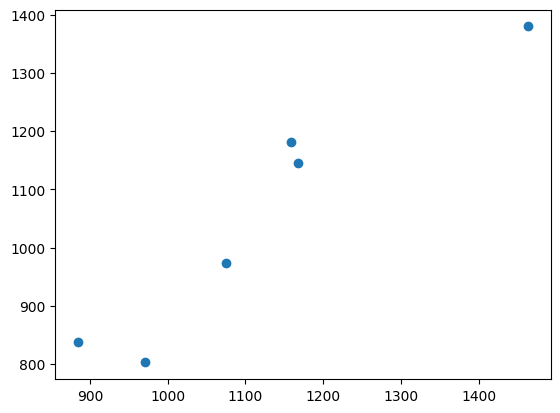

In [40]:
plt.scatter(y_test,y_pred) ## If there is a linear relationship between them then only our model has performed well.

In [ ]:
residuals=y_test-y_pred
print(residuals) ## residuals = errors

8     -21.746681
16    168.257203
0      84.165430
18     45.474004
11    101.146860
9      22.036518
Name: index_price, dtype: float64


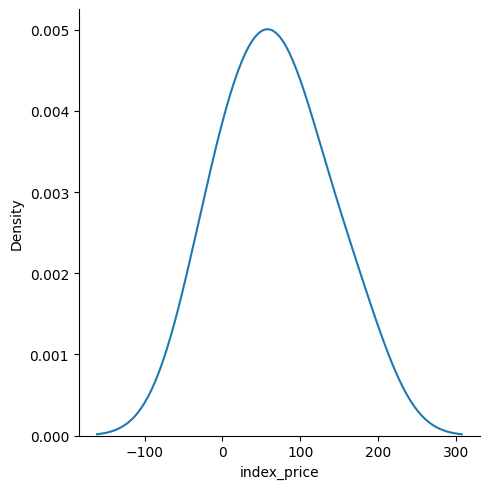

In [ ]:
## Plot this residuals
sns.displot(residuals,kind='kde') ## Residuals should follow normal distribution.
## If it forms something like/similar to normal distribution then our model performed well. 

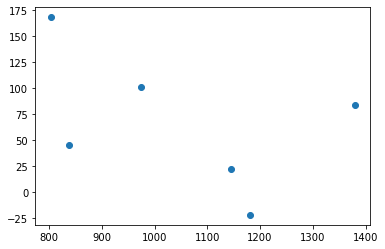

In [ ]:
## scatter plot with respect to prediction and residuals
plt.scatter(y_pred,residuals)
## If it follows some pattern, then there is some issue with this model(i.e uniformly distributed)

In [43]:
## OLS Linear Regression
import statsmodels.api as sm
model=sm.OLS(y_train,X_train).fit() ## ## It creates and trains a Linear Regression model using Ordinary Least Squares (OLS).
## ## sm.OLS(dependent_variable, independent_variables) -> This part only creates the regression model structure
## .fit() -> This actually trains the model. It calculates: Coefficients (β values), Best regression line, Statistical measures

In [44]:
model.summary()

c:\Users\Dell\anaconda3\envs\venv\lib\site-packages\scipy\stats\_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=18 observations were given.
  return hypotest_fun_in(*args, **kwds)


<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:            index_price   R-squared (uncentered):                   0.035
Model:                            OLS   Adj. R-squared (uncentered):             -0.086
Method:                 Least Squares   F-statistic:                             0.2880
Date:                Thu, 12 Feb 2026   Prob (F-statistic):                       0.754
Time:                        23:52:03   Log-Likelihood:                         -150.85
No. Observations:                  18   AIC:                                      305.7
Df Residuals:                      16   BIC:                                      307.5
Df Model:                           2                                                  
Covariance Type:            nonrobust                                                  
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
x1            88.2728    658.295      0.134      0.895   -1307.250    1483.796
x2          -116.2572    658.295     -0.177      0.862   -1511.780    1279.266
==============================================================================
Omnibus:                        0.598   Durbin-Watson:                   0.007
Prob(Omnibus):                  0.741   Jarque-Bera (JB):                0.567
Skew:                          -0.361   Prob(JB):                        0.753
Kurtosis:                       2.517   Cond. No.                         4.78
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [45]:
print(regression.coef_)

[  88.27275507 -116.25716066]
